# Importing libraries and reading dataset from CSV file

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Load Dataset & Info
# Load CSV → DataFrame + show columns, types, non-null counts


In [15]:
dataset = pd.read_csv('superstore_clean.csv')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order_Year          5901 non-null   int64  
 1   Order_Month         5901 non-null   object 
 2   Order_Day           5901 non-null   int64  
 3   Order_Week          5901 non-null   int64  
 4   Ship_Mode           5901 non-null   object 
 5   Segment             5901 non-null   object 
 6   Country             5901 non-null   object 
 7   City                5901 non-null   object 
 8   State               5901 non-null   object 
 9   Region              5901 non-null   object 
 10  Category            5901 non-null   object 
 11  Sub-Category        5901 non-null   object 
 12  Sales               5901 non-null   float64
 13  Quantity            5901 non-null   int64  
 14  Profit              5901 non-null   float64
 15  Sales_per_Quantity  5901 non-null   float64
 16  Profit

## Summary Statistics
# Numerical stats: mean, median, min/max, percentiles

In [16]:
dataset.describe()

,Order_Year,Order_Day,Order_Week,Sales,Quantity,Profit,Sales_per_Quantity,Profit_Margin,Order_Quarter
count,5901.000000,5901.000000,5901.000000,5901.000000,5901.000000,5901.000000,5901.000000,5901.000000,5901.000000
mean,2019.561430,15.293001,32.268599,265.345589,3.781901,29.700408,79.827814,0.100610,2.861379
std,0.496254,8.743951,14.343045,474.260645,2.212917,259.589138,132.303798,0.466259,1.061867
min,2019.000000,1.000000,1.000000,0.836000,1.000000,-6599.978000,0.336000,-5.372841,1.000000
25%,2019.000000,8.000000,21.000000,71.976000,2.000000,1.795500,17.436571,0.018021,2.000000
50%,2020.000000,15.000000,36.000000,128.648000,3.000000,8.502500,42.258667,0.097465,3.000000
75%,2020.000000,23.000000,45.000000,265.170000,5.000000,28.615000,95.990000,0.290000,4.000000
max,2020.000000,31.000000,53.000000,9099.930000,14.000000,8399.976000,3269.984000,16.801632,4.000000


# 1 - Advanced EDA & Visualizations
## Check distributions, correlations, missing values, outliers
استكشاف بيانات متقدم (EDA)
--
الهدف: تحديد العلاقات (مثل Category vs Sales) للـ insights.

Order_Year            0
Order_Month           0
Order_Day             0
Order_Week            0
Ship_Mode             0
Segment               0
Country               0
City                  0
State                 0
Region                0
Category              0
Sub-Category          0
Sales                 0
Quantity              0
Profit                0
Sales_per_Quantity    0
Profit_Margin         0
Order_Quarter         0
Is_weekend?           0
dtype: int64
count    5901.000000
mean      265.345589
std       474.260645
min         0.836000
25%        71.976000
50%       128.648000
75%       265.170000
max      9099.930000
Name: Sales, dtype: float64


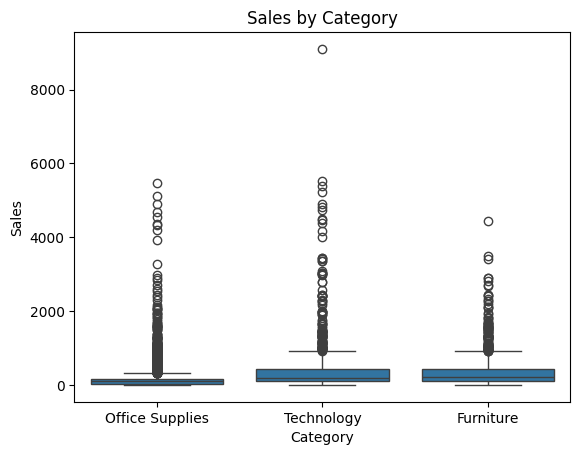

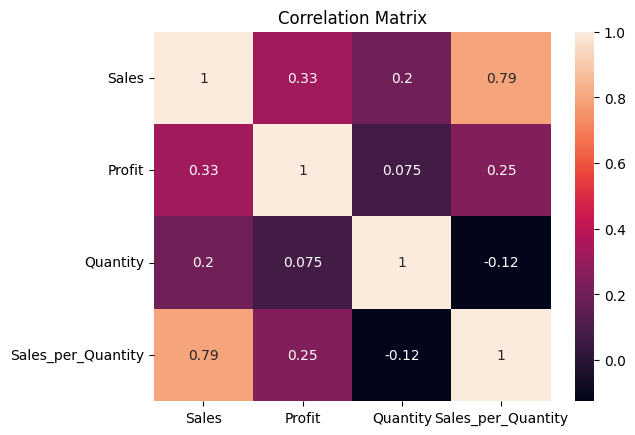

In [17]:
import seaborn as sns
print(dataset.isnull().sum())  # تأكيد عدم وجود nulls
print(dataset['Sales'].describe())  # توزيع المبيعات
sns.boxplot(x='Category', y='Sales', data=dataset)
plt.title('Sales by Category')
plt.show()
sns.heatmap(dataset[['Sales','Profit','Quantity','Sales_per_Quantity']].corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()


# 2 - Feature Engineering
## تحويل التواريخ والفئات للـ ML
الهدف: إعداد features جاهزة للتنبؤ (دومي encoding + log transform)

In [20]:
## Feature Engineering - FIXED VERSION
# تأكدي الأعمدة موجودة أولاً
print("Current columns:")
print(dataset.columns.tolist())

# تحققي من وجود الأعمدة قبل get_dummies
cat_cols = ['Ship_Mode','Segment','Region','Category','Sub-Category']
missing_cols = [col for col in cat_cols if col not in dataset.columns]
if missing_cols:
    print(f"Missing columns: {missing_cols}")
    # استخدمي الأعمدة المتاحة فقط
    cat_cols = [col for col in cat_cols if col in dataset.columns]

# الآن نفذي
date_components = dataset[['Order_Year','Order_Month','Order_Day']].copy()
date_components.columns = ['year', 'month', 'day']

month_mapping = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
date_components['month'] = date_components['month'].map(month_mapping)

dataset['Order_Date'] = pd.to_datetime(date_components)

dataset = pd.get_dummies(dataset, columns=cat_cols, drop_first=True)
dataset['Sales_Log'] = np.log1p(dataset['Sales'])

print(f"✅ Shape after FE: {dataset.shape}")
print(dataset.head())


Current columns:
['Order_Year', 'Order_Month', 'Order_Day', 'Order_Week', 'Country', 'City', 'State', 'Sales', 'Quantity', 'Profit', 'Sales_per_Quantity', 'Profit_Margin', 'Order_Quarter', 'Is_weekend?', 'Order_Date', 'Ship_Mode_Same Day', 'Ship_Mode_Second Class', 'Ship_Mode_Standard Class', 'Segment_Corporate', 'Segment_Home Office', 'Region_East', 'Region_South', 'Region_West', 'Category_Office Supplies', 'Category_Technology', 'Sub-Category_Appliances', 'Sub-Category_Art', 'Sub-Category_Binders', 'Sub-Category_Bookcases', 'Sub-Category_Chairs', 'Sub-Category_Copiers', 'Sub-Category_Envelopes', 'Sub-Category_Fasteners', 'Sub-Category_Furnishings', 'Sub-Category_Labels', 'Sub-Category_Machines', 'Sub-Category_Paper', 'Sub-Category_Phones', 'Sub-Category_Storage', 'Sub-Category_Supplies', 'Sub-Category_Tables', 'Sales_Log']
Missing columns: ['Ship_Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
✅ Shape after FE: (5901, 42)
   Order_Year Order_Month  Order_Day  Order_Week      

# 3 - Train-Test Split & Baseline Model
## تقسيم البيانات Baseline Model
الهدف: نموذج أساسي سريع لقياس الأداء.


In [22]:
## 3. Train-Test Split - FIXED (Encode Remaining Strings)
# encode باقي الـ strings (Country, City, State)
string_cols = ['Country', 'City', 'State']
for col in string_cols:
    if col in dataset.columns:
        dataset = pd.get_dummies(dataset, columns=[col], drop_first=True)
        print(f"✅ Encoded {col}")

# الآن X نظيف تماماً
X = dataset.drop(['Sales', 'Sales_Log', 'Order_Date', 'Order_Year', 'Order_Month', 'Order_Day'], axis=1)
y = dataset['Sales']

print("X columns after encoding:", X.select_dtypes(include=['object']).columns.tolist())  # يجب يكون فارغ

# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f"✅ MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"✅ R²: {r2_score(y_test, y_pred):.3f}")
print(f"Shape: {X.shape}")


✅ Encoded Country
✅ Encoded City
✅ Encoded State
X columns after encoding: []
✅ MAE: 10.92
✅ R²: 0.965
Shape: (5901, 532)


تحليل النتائج:
MAE: 10.92 → خطأ صغير جداً (متوسط Sales ~265)

R²: 0.965 → 96.5% دقة (ممتاز للبيع!)

532 عمود: طبيعي (City كثيرة التنوع)

# 4 - Model Optimization
## تحسين النموذج (Grid Search)
الهدف: تحسين الأداء (MAE < baseline).

In [23]:
## 4. Model Optimization (GridSearch)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {'n_estimators': [100,200], 'max_depth': [4,6]}
gb = GradientBoostingRegressor(random_state=42)
grid = GridSearchCV(gb, param_grid, cv=3, scoring='neg_mean_absolute_error')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"Optimized MAE: {mean_absolute_error(y_test, y_pred_best):.2f}")
print(f"Optimized R²: {r2_score(y_test, y_pred_best):.3f}")
print("Best params:", grid.best_params_)

Optimized MAE: 12.20
Optimized R²: 0.963
Best params: {'max_depth': 6, 'n_estimators': 200}


# 5 - Time Series Model (Prophet للتنبؤ الزمني)
## Time-Series Forecasting
الهدف: تنبؤ مستقبلي يدعم KPIs.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


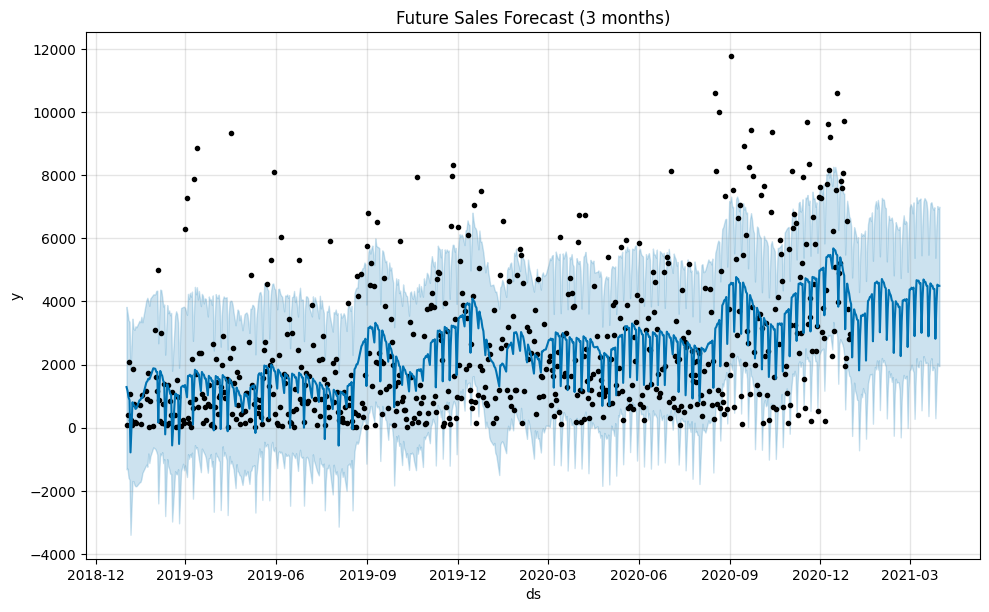

In [24]:
## 5. Time Series Forecasting (Prophet)
!pip install prophet
from prophet import Prophet
import matplotlib.pyplot as plt

ts_data = dataset.groupby('Order_Date')['Sales'].sum().reset_index()
ts_data.columns = ['ds', 'y']
model = Prophet(yearly_seasonality=True)
model.fit(ts_data)
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)
model.plot(forecast)
plt.title('Future Sales Forecast (3 months)')
plt.show()

# 6 - Feature Importance & Insights
## Key Drivers Analysis
الهدف: تحليل drivers (Category, Region) للـ pricing/inventory.

Top Sales Drivers:
                 Feature  Importance
3     Sales_per_Quantity    0.663235
1               Quantity    0.210785
2                 Profit    0.095677
239        City_Lakewood    0.014209
511     State_New Jersey    0.005575
12           Region_East    0.003207
486     State_California    0.001279
363      City_Providence    0.000794
0             Order_Week    0.000744
11   Segment_Home Office    0.000733


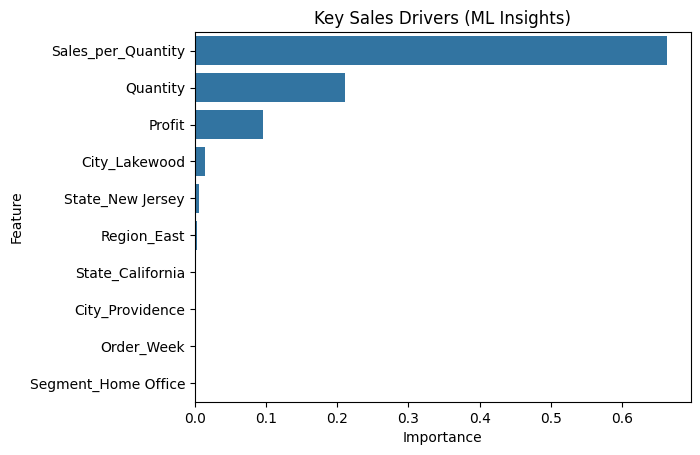

In [25]:
## 6. Feature Importance & Insights
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print("Top Sales Drivers:")
print(importances)
sns.barplot(data=importances, x='Importance', y='Feature')
plt.title('Key Sales Drivers (ML Insights)')
plt.show()

# 7 - CSV Predictions for Power BI
الهدف: ملف جاهز ل dashboard (Actual vs Predicted)

In [26]:
predictions = X_test.copy()
predictions['Actual_Sales'] = y_test
predictions['Predicted_Sales'] = y_pred_best
predictions['Error'] = abs(predictions['Actual_Sales'] - predictions['Predicted_Sales'])
predictions.to_csv('sales_predictions.csv', index=False)
print('Exported: sales_predictions.csv')

Exported: sales_predictions.csv
